<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/Multi_Layer_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Multi-Layer Perceptron (MLP)

A **Multi-Layer Perceptron (MLP)** is a fundamental type of artificial neural network. It consists of multiple layers of interconnected nodes (neurons) and is used for various tasks, including classification, regression, and pattern recognition.

### Architecture of an MLP:

An MLP typically has at least three layers:

1.  **Input Layer:** This is the first layer of the network. Each node in this layer corresponds to a feature in the input data. It simply passes the input values to the next layer and does not perform any computation.

2.  **Hidden Layer(s):** These are the intermediate layers between the input and output layers. MLPs can have one or more hidden layers, hence the term "multi-layer." Each neuron in a hidden layer receives inputs from the previous layer, performs a weighted sum of these inputs, adds a bias, and then applies an activation function. The activation function introduces non-linearity, allowing the network to learn complex patterns.

3.  **Output Layer:** This is the final layer of the network. The number of neurons in this layer depends on the type of problem being solved. For binary classification, there might be one output neuron; for multi-class classification, there could be one neuron per class; and for regression, there might be one or more neurons representing the predicted continuous values. Similar to hidden layers, output neurons also perform a weighted sum and apply an activation function (e.g., softmax for classification, linear for regression).

### How an MLP Works (Forward Propagation):

1.  **Input Reception:** The input layer receives the raw data.
2.  **Weighted Sum:** Each neuron in a subsequent layer (hidden or output) computes a weighted sum of its inputs from the previous layer. This can be represented as:  `z = Σ (w_i * x_i) + b`, where `x_i` are the inputs, `w_i` are the weights, and `b` is the bias.
3.  **Activation Function:** The weighted sum `z` is then passed through an activation function `f` (e.g., ReLU, sigmoid, tanh) to produce the neuron's output: `a = f(z)`. This output becomes an input to the neurons in the next layer.
4.  **Layer-by-Layer Computation:** This process is repeated layer by layer until the output layer produces the final prediction.

### Training an MLP (Backpropagation):

MLPs are typically trained using an algorithm called **backpropagation**. The general steps are:

1.  **Forward Pass:** Input data is fed through the network to generate an output prediction.
2.  **Loss Calculation:** The predicted output is compared to the actual target output using a loss function (e.g., mean squared error for regression, cross-entropy for classification) to calculate the error.
3.  **Backward Pass (Backpropagation):** The error is then propagated backward through the network, from the output layer to the input layer. During this process, the algorithm calculates the gradient of the loss function with respect to each weight and bias in the network.
4.  **Weight Update:** An optimization algorithm (e.g., gradient descent, Adam) uses these gradients to adjust the weights and biases in a way that minimizes the loss. This iterative process allows the network to learn and improve its predictions over time.

### Figure:

Imagine a diagram with three vertical columns of circles:

*   **Leftmost Column (Input Layer):** Let's say it has 3 circles, labeled `x1`, `x2`, `x3`. These are your input features.
*   **Middle Column (Hidden Layer):** This column would have several circles (e.g., 4 or 5), labeled `h1`, `h2`, `h3`, `h4`. Each circle in the input layer is connected to every circle in the hidden layer with an arrow, representing the weighted connections.
*   **Rightmost Column (Output Layer):** This column would have circles representing the output. For example, for a binary classification, it might have 1 circle labeled `y_hat`. Each circle in the hidden layer is connected to every circle in the output layer with an arrow.

Each arrow between layers would implicitly represent a weight `w`, and each circle in the hidden and output layers would have an associated bias `b` and an activation function applied to its summed input.

### MLP Example: Classification with scikit-learn

This example demonstrates a basic Multi-Layer Perceptron for a classification problem. We will:
1.  Generate a synthetic dataset.
2.  Initialize and train an `MLPClassifier`.
3.  Evaluate its performance.

### Explanation of the Code:

*   **`make_classification`**: This function from `sklearn.datasets` generates a random n-class classification problem. Here, we create a binary classification problem (2 classes) with 2 input features.
*   **`train_test_split`**: We split our dataset into training and testing sets. The model learns from the training data and is then evaluated on the unseen test data to assess its generalization ability.
*   **`MLPClassifier`**: This is the core of our example. It's the implementation of a Multi-Layer Perceptron for classification:
    *   `hidden_layer_sizes=(10, 5)`: Defines the architecture of the hidden layers. In this case, we have two hidden layers: the first has 10 neurons, and the second has 5 neurons.
    *   `activation='relu'`: Specifies the activation function for the hidden layers as the Rectified Linear Unit. This introduces non-linearity, allowing the MLP to learn complex relationships.
    *   `solver='adam'`: The optimization algorithm used to update the weights and biases during training. Adam is a popular and efficient choice.
    *   `max_iter=1000`: The maximum number of epochs (iterations over the training data) the solver will run.
    *   `random_state=42`: Ensures reproducibility of the results.
*   **`mlp.fit(X_train, y_train)`**: This is where the model learns. The `fit` method takes the training features (`X_train`) and their corresponding labels (`y_train`) and adjusts the internal weights and biases to minimize the prediction error.
*   **`mlp.predict(X_test)`**: After training, we use the `predict` method to get the model's predictions on the test set.
*   **`accuracy_score(y_test, y_pred)`**: This metric calculates the proportion of correctly classified instances, giving us an idea of the model's performance.

This simple example demonstrates the fundamental steps of creating, training, and evaluating an MLP for a classification task. The `hidden_layer_sizes` and `activation` parameters are key to defining the network's structure and its ability to learn complex patterns.

In [1]:
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification

# 1. Generate a synthetic dataset for classification
# We'll create 100 samples with 2 features, 2 classes, and some noise.
X, y = make_classification(n_samples=100, n_features=2, n_informative=2,
                           n_redundant=0, n_repeated=0, n_classes=2,
                           n_clusters_per_class=1, random_state=42)

print("Generated dataset shape (X, y):")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}\n")

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Dataset split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}\n")

# 2. Initialize and train the MLP Classifier
# hidden_layer_sizes=(10, 5) means two hidden layers: first with 10 neurons, second with 5.
# activation='relu' is the Rectified Linear Unit activation function.
# max_iter=1000 increases the number of epochs for convergence.
mlp = MLPClassifier(hidden_layer_sizes=(10, 5), activation='relu', solver='adam', max_iter=1000, random_state=42)

print("Training the MLP Classifier...")
mlp.fit(X_train, y_train)
print("Training complete.\n")

# 3. Make predictions on the test set
y_pred = mlp.predict(X_test)

# 4. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy:.4f}")

# You can also inspect the model's parameters (weights and biases)
# print("\nNumber of layers:", mlp.n_layers_)
# print("Weights (coefficients):")
# for i, coef in enumerate(mlp.coefs_):
#     print(f"  Layer {i}: {coef.shape}")
# print("Biases (intercepts):")
# for i, intercept in enumerate(mlp.intercepts_):
#     print(f"  Layer {i}: {intercept.shape}")

Generated dataset shape (X, y):
X shape: (100, 2)
y shape: (100,)

Dataset split into training and testing sets:
X_train shape: (70, 2)
X_test shape: (30, 2)
y_train shape: (70,)
y_test shape: (30,)

Training the MLP Classifier...
Training complete.

Model Accuracy on Test Set: 1.0000


#Explanation of Images

# Multi-Layer Perceptron (MLP) Intuition

Understanding how multiple perceptrons combine to form a powerful model.

## 1. Single Perceptron Limitation

A single perceptron creates a linear decision boundary (a straight line).

- It divides data into two regions.
- However, real-world data is often not linearly separable.
- Some points are misclassified.

Example:
P(y) = 0.7 → Model is 70% confident but still makes errors.

## 2. Using Multiple Perceptrons

We introduce another perceptron with a different decision boundary.

- First perceptron → P(y) = 0.7
- Second perceptron → P(y) = 0.8

Each perceptron captures a different pattern in the data.

## 3. Hidden Layer (Core Idea of MLP)

Each perceptron acts as a neuron in the hidden layer.

Instead of relying on one decision boundary, we combine multiple outputs:

h1 = 0.7  
h2 = 0.8  

These become inputs to the next layer.

## 4. Combining Outputs

The outputs are combined using a weighted sum:

z = w1*h1 + w2*h2 + b

For simplicity:
z = 0.7 + 0.8 = 1.5

## 5. Activation Function (Sigmoid)

We pass z into a sigmoid function:

σ(z) = 1 / (1 + e^(-z))

For z = 1.5:
σ(1.5) ≈ 0.82

Final prediction:
P(y) = 0.82

In [2]:
import numpy as np

# outputs from hidden layer (perceptrons)
h1 = 0.7
h2 = 0.8

# weights (assume 1 for simplicity)
w1 = 1
w2 = 1
b = 0

# weighted sum
z = w1*h1 + w2*h2 + b

# sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

output = sigmoid(z)

print("z =", z)
print("Final Prediction =", output)

z = 1.5
Final Prediction = 0.8175744761936437


## 6. Final Intuition

- Each perceptron learns a simple pattern.
- MLP combines multiple patterns.
- This allows the model to learn complex, non-linear boundaries.

Think of it like:

Perceptron 1 → "70% sure"
Perceptron 2 → "80% sure"

Final output → "82% sure"

This is why MLP is more powerful than a single perceptron.

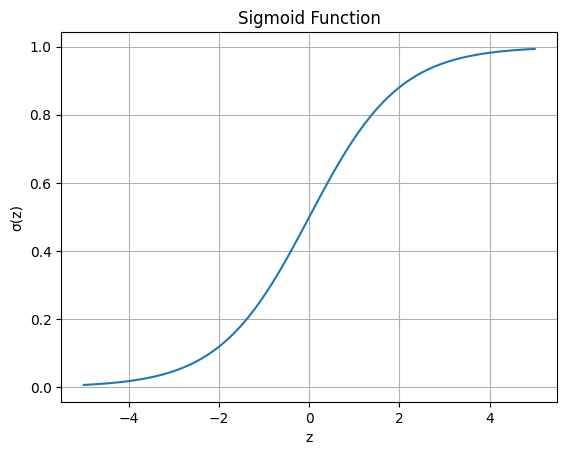

In [3]:
import matplotlib.pyplot as plt

# sample sigmoid curve
x = np.linspace(-5, 5, 100)
y = 1 / (1 + np.exp(-x))

plt.plot(x, y)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("σ(z)")
plt.grid()
plt.show()

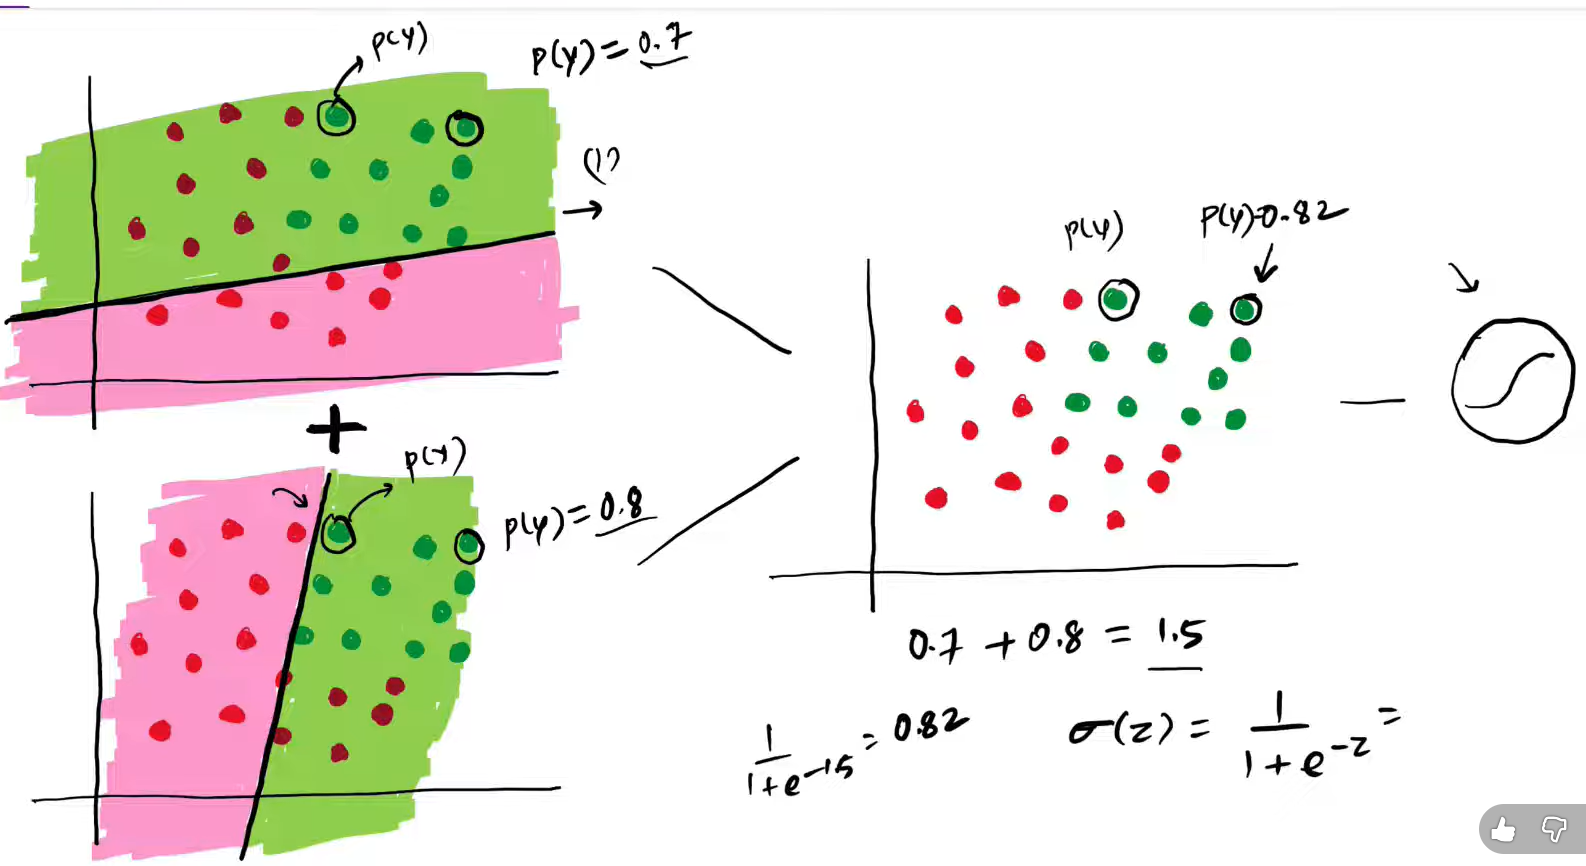

# Multi-Layer Perceptron (MLP) – Non-Linear Decision Boundary Intuition

This diagram explains how multiple perceptrons combine to form a **curved (non-linear) decision boundary**.

---

## 🔴 1. First Perceptron

- The first perceptron creates a linear boundary (straight line).
- It separates the data into two regions:
  - Green → Class 1
  - Pink → Class 0

However:
- Some red points are misclassified.
- Prediction for a sample point:
  
  P(y) = 0.7

This means the model is 70% confident.

---

## 🟢 2. Second Perceptron

- A second perceptron creates a different boundary.
- It captures another pattern in the data.

Prediction for the same point:

P(y) = 0.8

Now we have two different "views" of the data.

---

## ➕ 3. Combining Both Perceptrons (Hidden Layer)

These two perceptrons act as **hidden neurons**.

Their outputs:

h1 = 0.7  
h2 = 0.8  

We combine them:

z = h1 + h2 = 0.7 + 0.8 = 1.5

---

## ⚡ 4. Non-Linearity Creates Curved Boundary

When we combine multiple linear boundaries:

- Each perceptron contributes a region
- Their combination creates a **curved decision boundary**

👉 This is shown on the right side of the diagram.

Instead of a straight line:
- The boundary bends to better fit the data
- Misclassification reduces

---

## 📉 5. Activation Function (Sigmoid)

We pass the combined value into sigmoid:

σ(z) = 1 / (1 + e^(-z))

For z = 1.5:

σ(1.5) ≈ 0.82

Final prediction:

P(y) = 0.82

---

## 🎯 6. Key Insight

- A single perceptron → only straight line
- Multiple perceptrons → combine to form curves

👉 This is why MLP can solve complex problems.

---

## 🧠 Final Intuition

Think of each perceptron as:

- Perceptron 1 → captures one pattern
- Perceptron 2 → captures another pattern

Final layer:
- Combines both → creates smarter decision

Result:
✔ Better accuracy  
✔ Flexible boundaries  
✔ Handles non-linear data  

---

## 🚀 Conclusion

Multi-Layer Perceptron works because:

- Hidden layers learn intermediate features
- Output layer combines them
- Non-linearity allows curved decision boundaries

This makes MLP much more powerful than a single perceptron.

In [4]:
import numpy as np

# hidden layer outputs
h1 = 0.7
h2 = 0.8

# combine
z = h1 + h2

# sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

print("z =", z)
print("Final Prediction =", sigmoid(z))

z = 1.5
Final Prediction = 0.8175744761936437


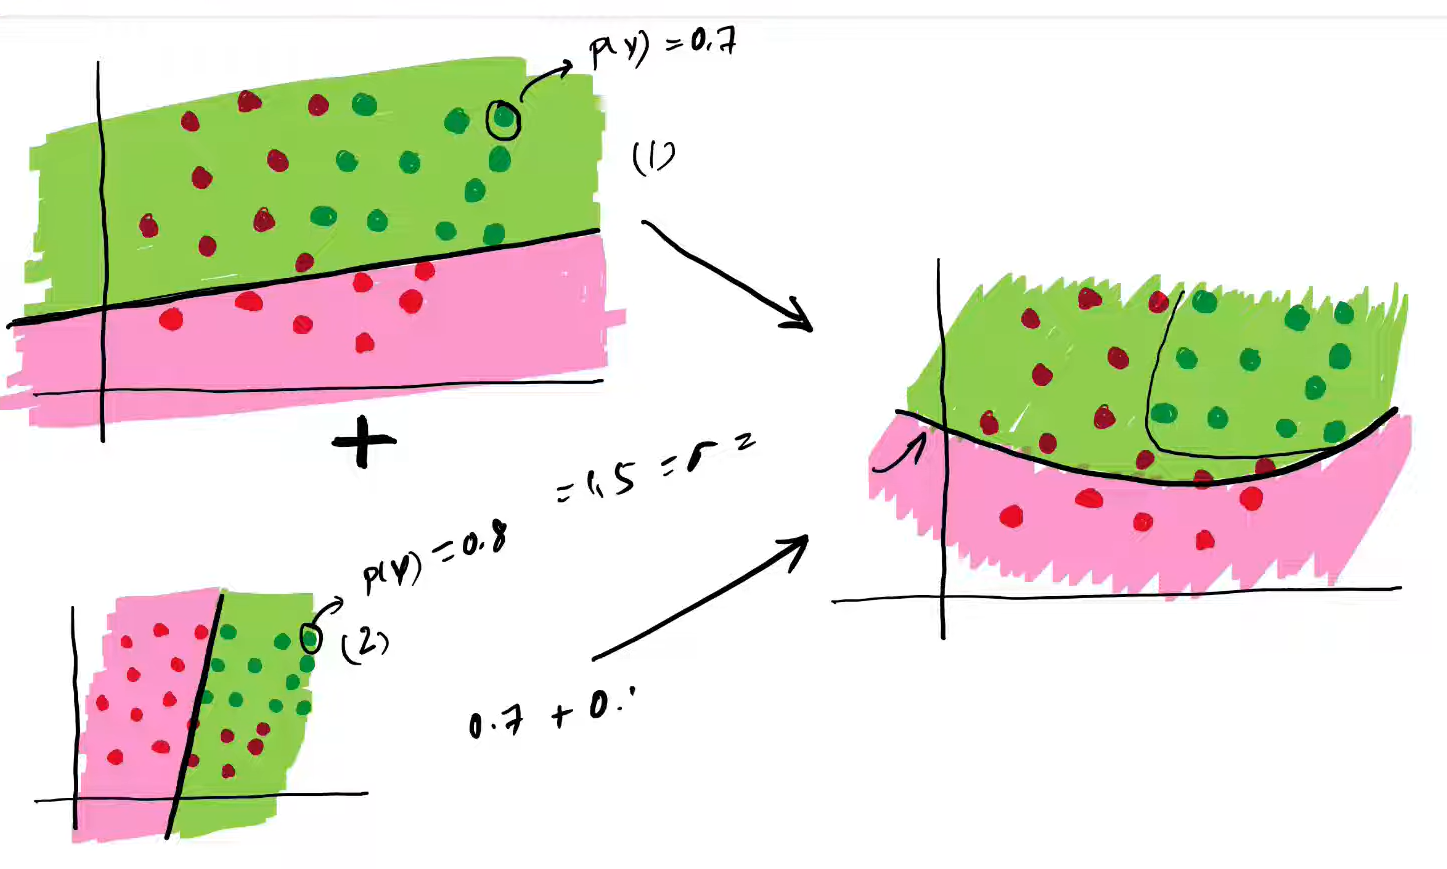

# Multi-Layer Perceptron (MLP) – Weights, Bias & Decision Boundary

This diagram explains how MLP combines multiple perceptrons using **weights and bias** to form a **non-linear decision boundary**.

---

## 🔴 1. Individual Perceptrons (Hidden Layer)

Each small circle represents a neuron (perceptron).

Each neuron computes:

z = w1*x + w2*y + b

Example from diagram:
- One neuron outputs: 6
- Another outputs: 3

These are **feature representations** learned from input.

---

## 🟢 2. Linear Decision Boundaries

Each perceptron creates a line:

Example equation:
5x + 4y + 3 = 0

👉 This is a straight line separating:
- Green region → Class 1
- Pink region → Class 0

Each perceptron learns a **different boundary**.

---

## ➕ 3. Combining Perceptrons

Outputs from hidden neurons are combined:

z = 10*h1 + 5*h2 + bias

From diagram:
- Weight 10 → importance of first boundary
- Weight 5 → importance of second boundary

👉 This means:
- Not all neurons are equally important

---

## ⚖️ 4. Role of Weights

Weights control **influence**:

- Larger weight → more impact
- Smaller weight → less impact

Example:
10*h1 + 5*h2

→ First neuron influences decision more than second

---

## 🎯 5. Role of Bias

Bias shifts the boundary:

bias = 3

👉 It moves the decision boundary:
- Up / Down
- Left / Right

Without bias:
- Boundary always passes through origin ❌

With bias:
- Boundary becomes flexible ✅

---

## 🌊 6. Final Curved Boundary

When we combine multiple linear boundaries:

- Each neuron creates a line
- Weighted combination bends the boundary

👉 Result:
A **curved decision boundary** (shown on right)

This helps:
✔ Fit complex data  
✔ Reduce misclassification  

---

## ⚡ 7. Final Output

Final neuron computes:

z = 10*h1 + 5*h2 + 3

Then applies activation function:

σ(z) = 1 / (1 + e^(-z))

Output:
ŷ (final prediction)

---

## 🧠 Final Intuition

- Hidden layer → learns multiple simple patterns
- Weights → decide importance of each pattern
- Bias → shifts decision boundary
- Output layer → combines everything

---

## 🚀 Key Takeaways

✔ Each neuron = linear boundary  
✔ MLP = combination of boundaries  
✔ Weights = importance  
✔ Bias = flexibility  
✔ Result = non-linear (curved) decision boundary  

This is why MLP is powerful for real-world data.

In [5]:
import numpy as np

# hidden layer outputs (example)
h1 = 6
h2 = 3

# weights
w1 = 10
w2 = 5
b = 3

# weighted sum
z = w1*h1 + w2*h2 + b

# sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

print("z =", z)
print("Final Prediction =", sigmoid(z))

z = 78
Final Prediction = 1.0


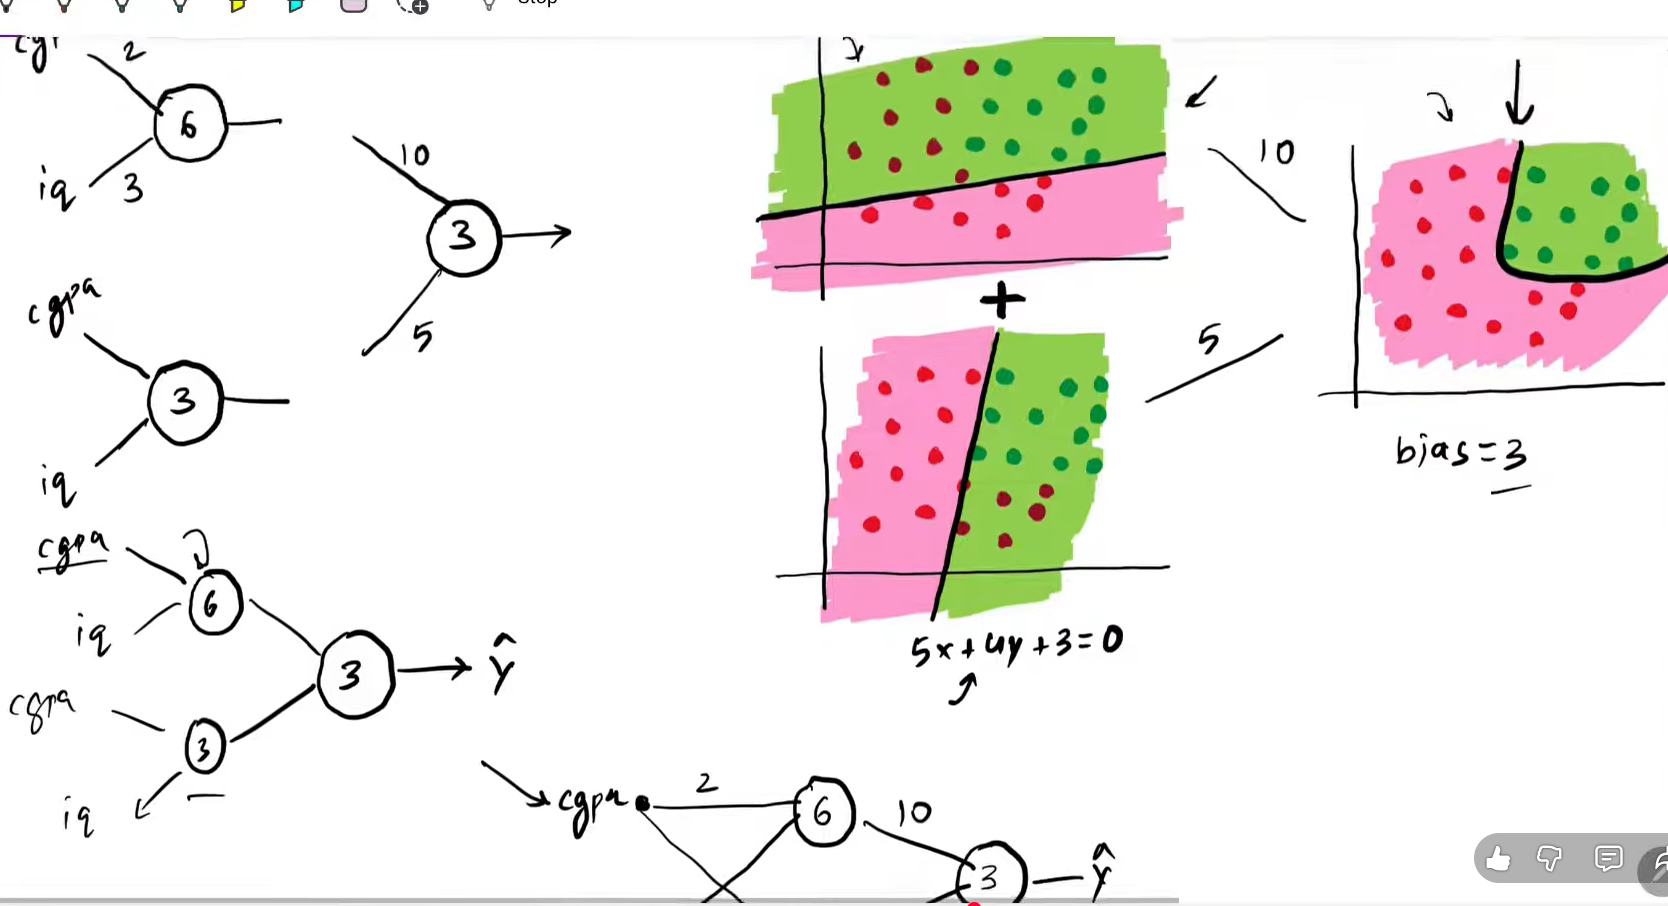

# Multi-Layer Perceptron (MLP) – Effect of Adding Hidden Nodes

This diagram explains how increasing the number of neurons in the hidden layer allows a neural network to learn **complex decision boundaries**.

---

## 🔢 1. Input Layer

We start with input features:

- CGPA  
- IQ  

These are fed into the neural network.

👉 Each input connects to all hidden neurons.

---

## 🧠 2. Hidden Layer (Multiple Neurons)

Each hidden neuron learns a **linear boundary (line)**.

From the diagram:

- Neuron (1) → Line 1  
- Neuron (2) → Line 2  
- Neuron (3) → Line 3  

Each line separates data differently.

👉 Important:
Each neuron = one straight-line decision boundary

---

## ➕ 3. Increasing Number of Nodes

As we add more neurons:

- More lines are created
- Each line captures a different pattern

👉 More nodes = more flexibility

---

## 🌊 4. Combining Multiple Lines

When these neurons are combined:

- Their outputs are merged in the next layer
- The final boundary is no longer a straight line

👉 Instead, it becomes a **closed shape (like a circle)**

---

## 🎯 5. Learning Complex Patterns

On the right side:

- Green points are inside a circular region
- Red points are outside

👉 A single perceptron CANNOT learn this ❌  
👉 MLP CAN learn this using multiple neurons ✅  

---

## ⚡ 6. Why This Happens

Each neuron creates a half-plane:

- One neuron → one cut  
- Multiple neurons → multiple cuts  

Combining these cuts forms:

✔ Curves  
✔ Shapes  
✔ Regions (like circles)

---

## 🧠 7. Neural Network Architecture

- Input layer → CGPA, IQ  
- Hidden layer → multiple neurons  
- Output layer → final prediction  

Each layer transforms data step by step.

---

## 🚀 Final Intuition

Think of neurons as:

- "Line creators"

MLP as:

- "Shape builder"

👉 More neurons = more lines = more complex shapes

---

## 📌 Key Takeaways

✔ Single perceptron → only straight line  
✔ Multiple neurons → multiple lines  
✔ Combined → curved / closed boundaries  
✔ More nodes → better learning capacity  

---

## 🎯 Conclusion

Adding nodes in hidden layer allows MLP to:

- Learn non-linear patterns  
- Fit complex datasets  
- Reduce classification errors  

This is the core power of deep learning.

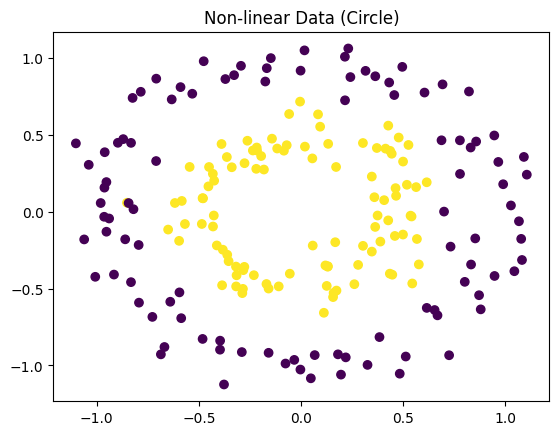

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# create non-linear data (circle)
X, y = make_circles(n_samples=200, noise=0.1, factor=0.5)

plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Non-linear Data (Circle)")
plt.show()

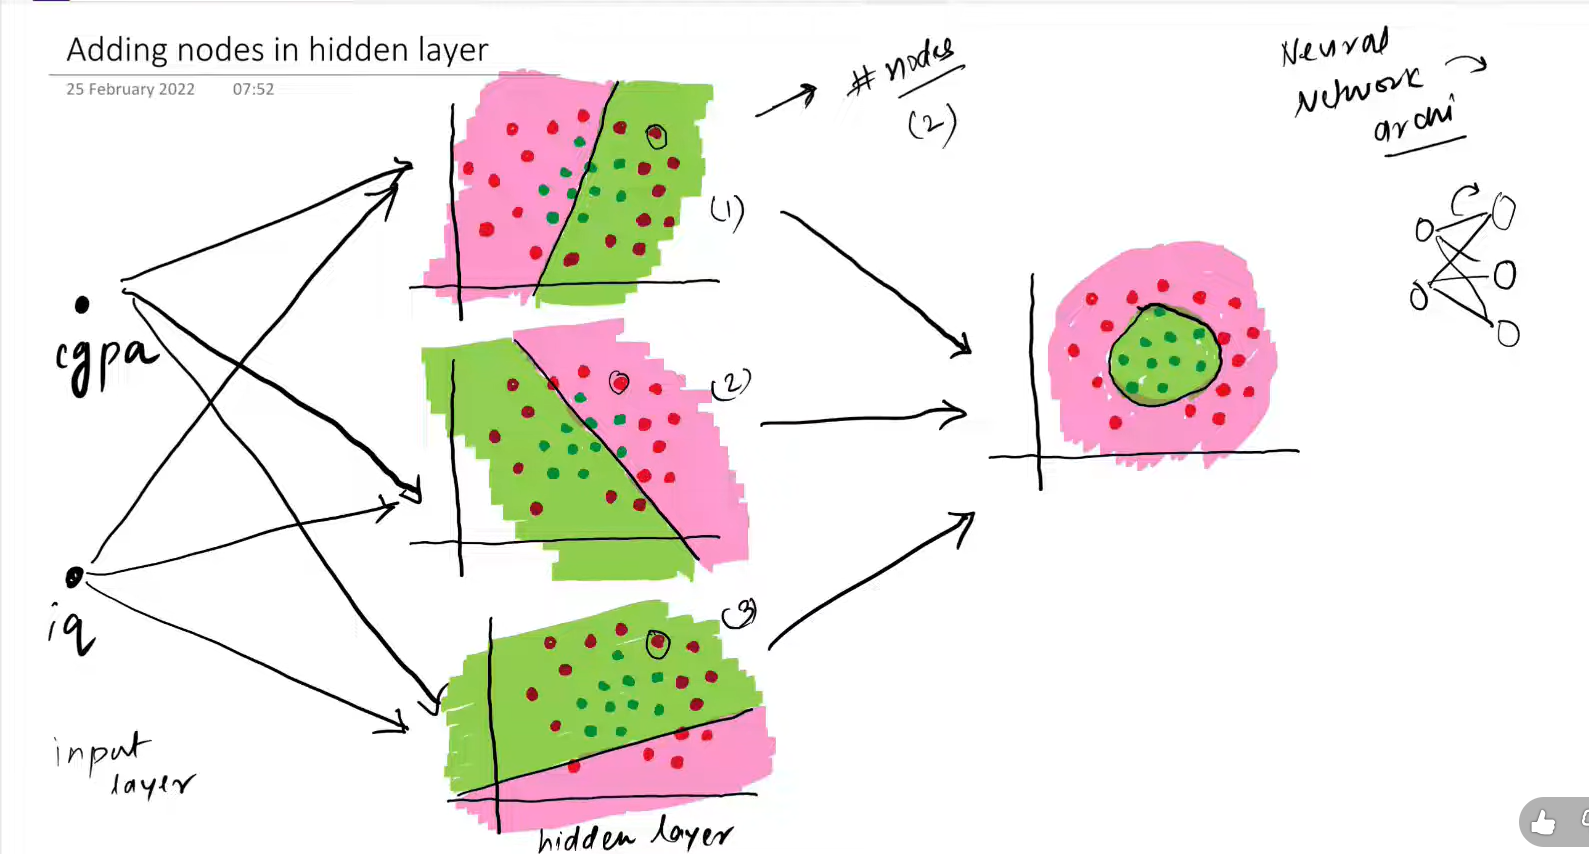

# Multi-Layer Perceptron (MLP) – Adding Input Nodes (Feature Expansion)

This diagram explains how increasing the number of input features changes the geometry of the problem.

---

## 🔢 1. Input Layer (Feature Space)

Initially, we have:

- CGPA  
- IQ  

This creates a **2D input space**.

👉 Each data point lies on a 2D plane.

---

## ➕ 2. Adding More Input Nodes

Now we add another feature:

- 12th Marks  

So inputs become:

(CGPA, IQ, 12th Marks)

👉 This creates a **3D space**.

---

## 📐 3. From Line to Plane

In 2D:
- Decision boundary = line

In 3D:
- Decision boundary = plane

Equation:

z = w1*x1 + w2*x2 + w3*x3 + b

👉 This represents a **plane in 3D space**

---

## ⚡ 4. Linear Combination

The model computes:

z = w1*(CGPA) + w2*(IQ) + w3*(12th marks) + b

👉 This is called a **linear combination of inputs**

---

## 🌊 5. Transformation of Space

From diagram:

- Blue surface → one transformation  
- Red surface → another transformation  

Weights (w1, w2) change how input space is shaped.

👉 Neural network reshapes data space.

---

## 🔄 6. Applying Activation Function

After computing z:

σ(z) = 1 / (1 + e^(-z))

👉 This introduces **non-linearity**

---

## 🎯 7. Why More Inputs Help

Adding more features:

✔ Provides more information  
✔ Improves separability  
✔ Makes classification easier  

Example:
- With only CGPA + IQ → hard to separate  
- Adding 12th marks → easier separation  

---

## 🧠 8. Final Intuition

- Input nodes = dimensions of data  
- More inputs → higher-dimensional space  
- Higher dimensions → easier separation  

👉 Neural networks use this to their advantage.

---

## 🚀 Key Takeaways

✔ 2 inputs → line boundary  
✔ 3 inputs → plane boundary  
✔ n inputs → hyperplane  

✔ More features → better representation  
✔ Combined with hidden layers → powerful model  

---

## 🎯 Conclusion

Adding input nodes increases the **dimensionality of data**, allowing the model to:

- Represent complex relationships  
- Improve classification  
- Learn better patterns  

This is why feature engineering is important in machine learning.

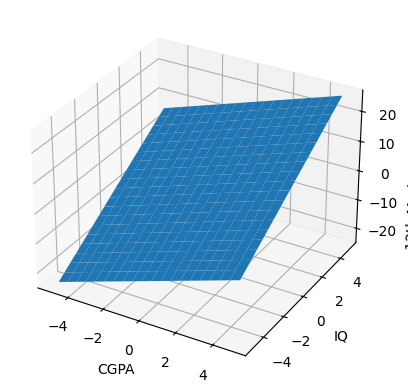

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# create grid
x = np.linspace(-5, 5, 20)
y = np.linspace(-5, 5, 20)
x, y = np.meshgrid(x, y)

# plane equation
z = 2*x + 3*y + 1

# plot
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(x, y, z)

ax.set_xlabel("CGPA")
ax.set_ylabel("IQ")
ax.set_zlabel("12th Marks (transformed)")

plt.show()

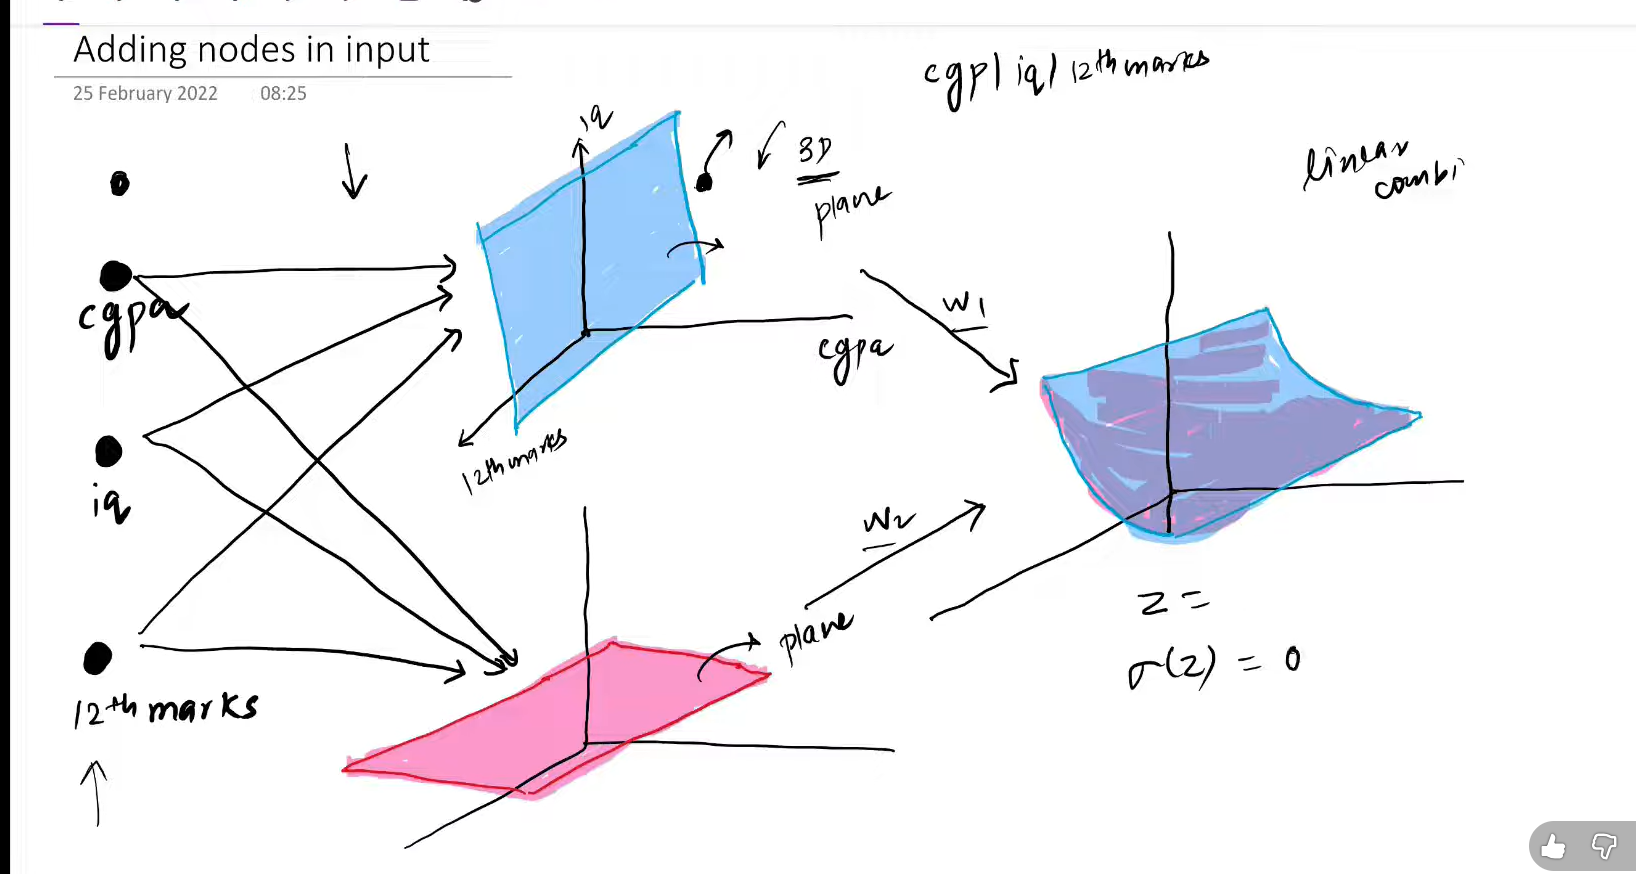

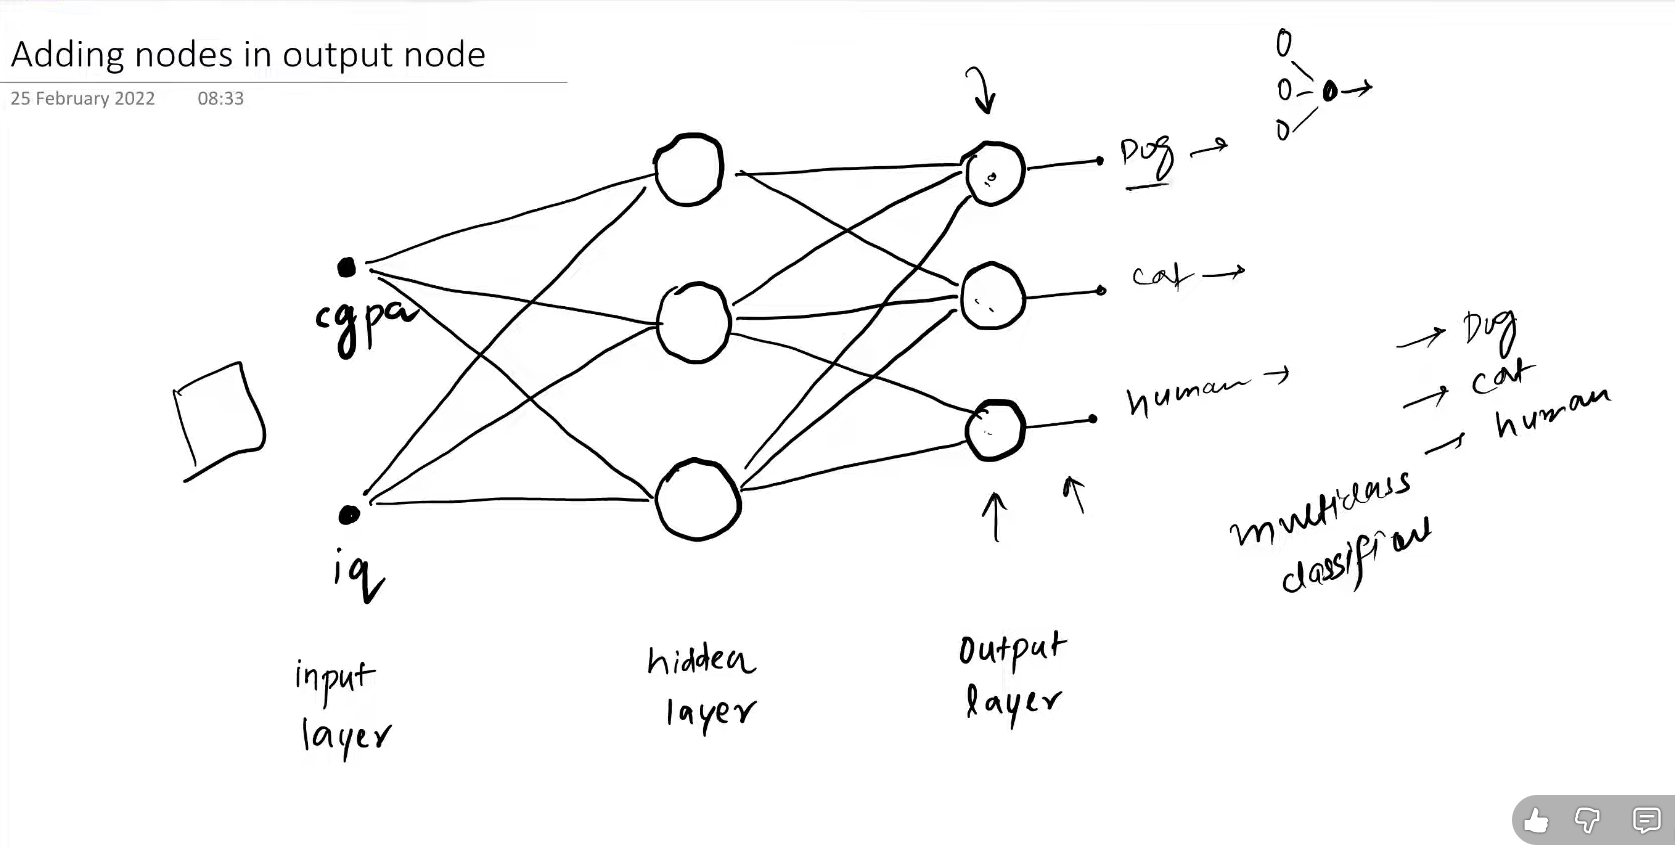

# Deep Neural Network (DNN) – Multi-Layer Learning Intuition

This diagram explains how adding multiple hidden layers allows a neural network to learn **highly complex decision boundaries**.

---

## 🔢 1. Input Layer

We start with input features:

- CGPA  
- IQ  

These are fed into the neural network.

---

## 🧠 2. Hidden Layer 1 (Basic Feature Learning)

- The first hidden layer creates simple linear boundaries (lines).
- Each neuron separates data in a basic way.

👉 Output:
- Rough separation of data
- Still many misclassifications

---

## 🔄 3. Hidden Layer 2 (Feature Transformation)

- The second hidden layer takes outputs from layer 1
- It combines them to create **curved boundaries**

👉 Now:
- Data is better separated
- Patterns become clearer

---

## 🌊 4. Deep Transformation (Multiple Layers)

As we add more hidden layers:

- Each layer transforms the feature space
- Boundaries become more flexible

👉 From:
- Straight lines → curves → complex shapes

---

## 🎯 5. Final Output Layer

- Combines all transformed features
- Produces final prediction

👉 Output boundary is highly non-linear (shown on right)

---

## ⚡ 6. Why Deep Networks Work

Each layer learns a different level of abstraction:

- Layer 1 → simple patterns (lines)
- Layer 2 → combinations (curves)
- Layer 3+ → complex shapes

👉 This is called **hierarchical learning**

---

## 🧠 7. Universal Function Approximation (UFA)

Deep Neural Networks can approximate **any function**.

👉 This is why:
- They can solve very complex problems
- Used in vision, NLP, etc.

---

## 🚀 Final Intuition

Think of layers as:

- Layer 1 → draws straight lines  
- Layer 2 → bends those lines  
- Layer 3 → combines bends into complex shapes  

👉 Final result:
A highly flexible decision boundary

---

## 📌 Key Takeaways

✔ More layers → deeper learning  
✔ Each layer transforms data  
✔ Complex patterns become learnable  
✔ Final boundary becomes highly non-linear  

---

## 🎯 Conclusion

Deep Neural Networks work because:

- They stack multiple transformations
- Each layer builds on previous one
- This allows learning of complex real-world patterns

This is the foundation of deep learning.

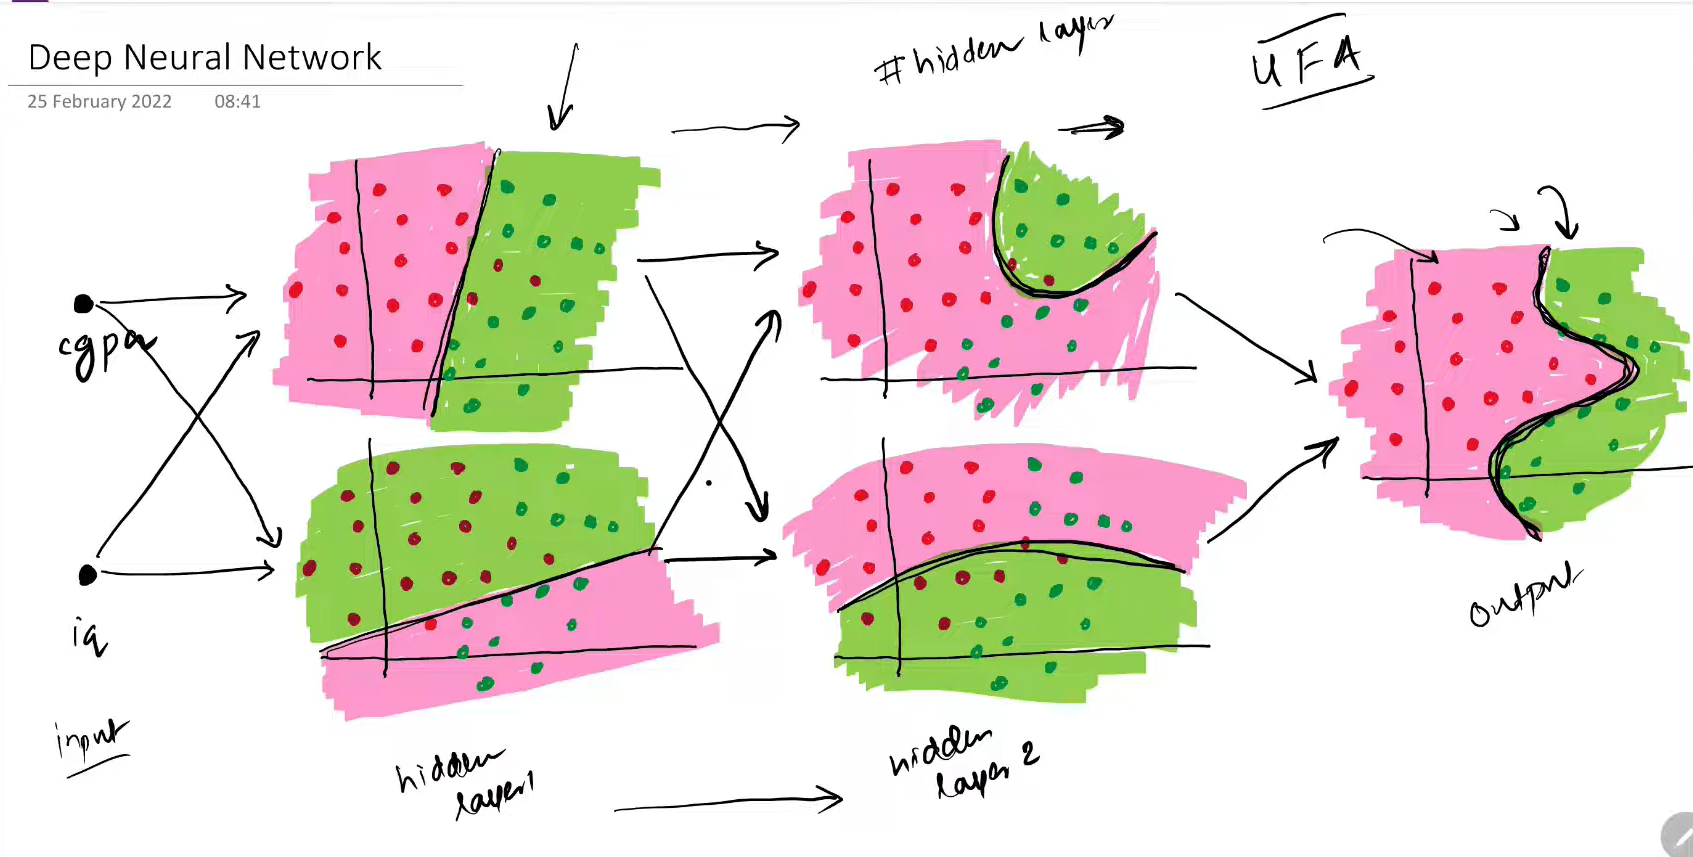

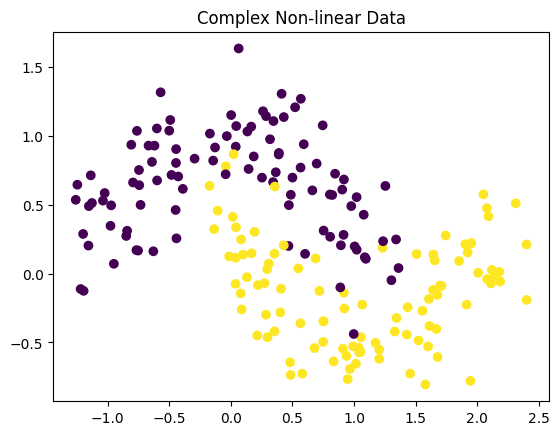

In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# generate complex data
X, y = make_moons(n_samples=200, noise=0.2)

plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Complex Non-linear Data")
plt.show()